In [1]:
from pint.models import get_model
from pint.simulation import make_fake_toas_uniform
from pint.residuals import WidebandTOAResiduals
from pint.logging import setup as setup_log

from enterprise_wideband.pulsar import WidebandPulsar
from enterprise_wideband.signals import WidebandTimingModel, WidebandMeasurementNoise
from enterprise_wideband.blocks import achromatic_red_noise_powerlaw_block
from enterprise.signals.signal_base import PTA

from io import StringIO
import numpy as np
import astropy.units as u

from PTMCMCSampler.PTMCMCSampler import PTSampler
import corner
import matplotlib.pyplot as plt

/home/abhimanyu/miniconda3/envs/enterprise/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


In [2]:
setup_log(level="WARNING")

1

In [3]:
par = """
    PSR         J1234+5678
    RAJ         12:34:56.789    1
    DECJ        +56:00:00.123   1
    PMRA        1e-10           0 
    PMDEC       1e-10           0
    POSEPOCH    55000
    F0          100.0           1
    F1          -1e-15          1
    PEPOCH      55000
    DM          10.0            1   
    DMEPOCH     55000
    TNREDAMP    -13
    TNREDGAM    2.5
    TNREDC      30
    EPHEM       DE440
    CLOCK       TT(BIPM2019)
    UNITS       TDB
    PLANET_SHAPIRO Y
"""

In [4]:
m = get_model(StringIO(par))

In [5]:
t = make_fake_toas_uniform(
    model=m,
    startMJD=54000,
    endMJD=56000,
    ntoas=5000,
    error=1*u.us,
    add_noise=True,
    add_correlated_noise=True,
    wideband=True,
)

WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setU

In [6]:
resids = WidebandTOAResiduals(t, m)

WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.


<ErrorbarContainer object of 3 artists>

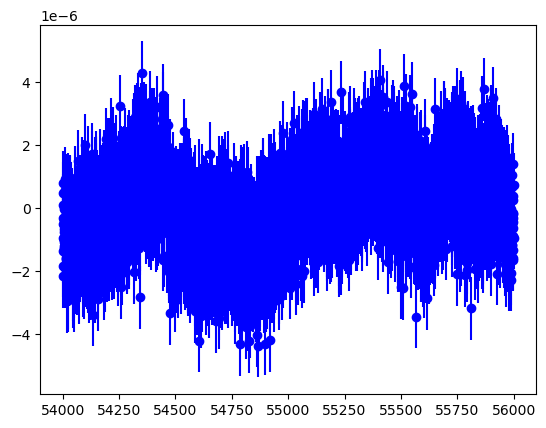

In [7]:
plt.errorbar(t.get_mjds(), resids.toa.calc_time_resids(), yerr=resids.toa.get_data_error(), fmt="ob")

In [8]:
psr = WidebandPulsar(t, m)

WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.
WARNING  (pint.models.noise_model       ): Log-spaced parameters are ignored because logmode, nlog, and f_min ALL neeed to be setUse: logmode > 0 and nlog > 0 and f_min > 0.


In [9]:
tm = WidebandTimingModel()
wn = WidebandMeasurementNoise(efac=1.0, dmefac=1.0)
rn = achromatic_red_noise_powerlaw_block(components=50, dropbin=True)

In [10]:
model = tm + wn + rn

In [11]:
pta = PTA([model(psr)])

In [12]:
print(pta.param_names)

['J1234+5678_powerlaw_achromatic_red_noise_gamma', 'J1234+5678_powerlaw_achromatic_red_noise_k_dropbin', 'J1234+5678_powerlaw_achromatic_red_noise_log10_A']


In [13]:
x0 = np.array([p.sample() for p in pta.params])

In [14]:
# dimension of parameter space
ndim = len(x0)

# initial jump covariance matrix
cov = np.diag(np.ones(ndim) * 0.01**2)

# intialize sampler
sampler = PTSampler(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir="chains/")

In [15]:
N = 100000
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Finished 1.00 percent in 0.371097 s Acceptance rate = 0.854

WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/enterprise/lib/python3.12/site-packages/enterprise/signals/parameter.py:70 RuntimeWarning: divide by zero encountered in log


Finished 10.00 percent in 2.989954 s Acceptance rate = 0.30143Adding DE jump with weight 50
Finished 100.00 percent in 25.315008 s Acceptance rate = 0.34311
Run Complete


In [16]:
chain = np.loadtxt("chains/chain_1.txt")
burn = int(0.25 * chain.shape[0])

In [17]:
labels = ["gamma_arn", "kdrop_arn", "log10_A_arn"]

true_values = [m["TNREDGAM"].value, m["TNREDC"].value, m["TNREDAMP"].value]

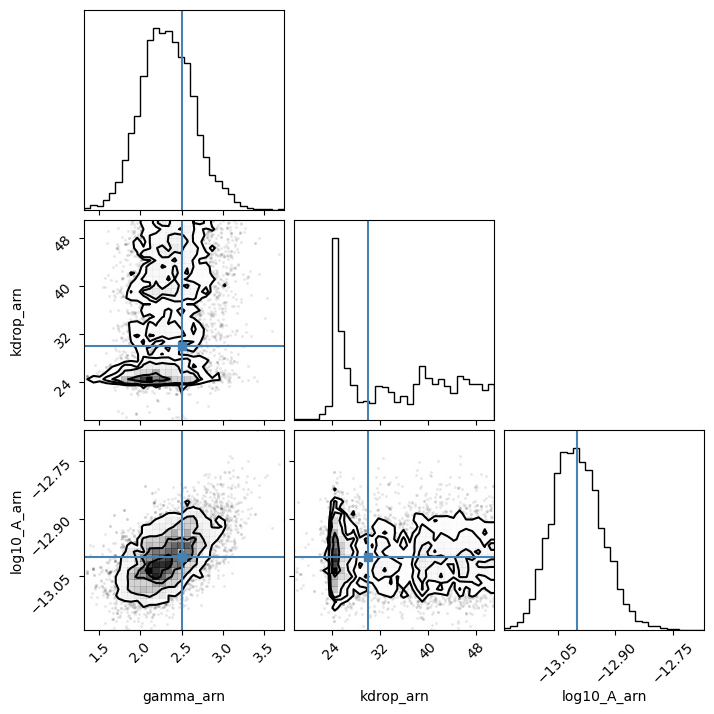

In [18]:
corner.corner(
    chain[burn:, :-4],
    bins=32,
    truths=true_values,
    labels=labels,
);